In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.layers import Dense
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/Pima indians diabetes dataset.csv')

In [6]:
df.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [7]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [8]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [10]:
df.shape

(760, 9)

In [11]:
x = df.drop('Outcome', axis = 1) # features
y = df['Outcome']  # target

In [12]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
X_train[:2]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
693,6,125,78.0,31,169.5,27.6,0.565,49
361,5,99,54.0,28,83.0,34.0,0.499,30


In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
print(X_train[:2])

[[ 0.64512746  0.1030075   0.47670843  0.23306932  0.59281566 -0.73860376
   0.25625114  1.3800358 ]
 [ 0.34999014 -0.75221442 -1.52390399 -0.12060659 -0.87670552  0.22798498
   0.05941259 -0.27166059]]


In [20]:
# Build a FFNN model
model = Sequential()
model.add(Dense(8, activation='relu', input_shape=[x.shape[1]]))  # Input layer
model.add(Dense(16, activation='relu'))                           # 1st Hidden layer
model.add(Dense(8, activation='relu'))                            # 2nd hidden layer
model.add(Dense(1, activation='sigmoid'))                         # Output layer

# Show model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361 (1.41 KB)

 Trainable params: 361 (1.41 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(X_train, y_train, epochs=25, validation_split=0.2)

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4897 - loss: 0.7009 - val_accuracy: 0.7295 - val_loss: 0.6610
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6543 - loss: 0.6746 - val_accuracy: 0.7787 - val_loss: 0.6375
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6749 - loss: 0.6573 - val_accuracy: 0.7623 - val_loss: 0.6113
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6872 - loss: 0.6370 - val_accuracy: 0.7869 - val_loss: 0.5850
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6975 - loss: 0.6176 - val_accuracy: 0.7869 - val_loss: 0.5566
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7099 - loss: 0.5944 - val_accuracy: 0.8033 - val_loss: 0.5300
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7243 - loss: 0.5693 - val_accuracy: 0.7951 - val_loss: 0.5001
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7284 - loss: 0.5441 - val_accuracy: 0.8197 - va

#### testing accuracy

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8684 - loss: 0.3654 
Test accuracy: 0.8684210777282715


#### Training accuracy

In [ ]:
train_loss, train_acc = model.evaluate(X_train, y_train)
print('Train accuracy:', train_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8618 - loss: 0.3501 
Train accuracy: 0.8618420958518982


# MSE ERROR

In [ ]:
# calculate mse error
from sklearn.metrics import mean_squared_error
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'MSE: {mse:.2f}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
MSE: 0.11


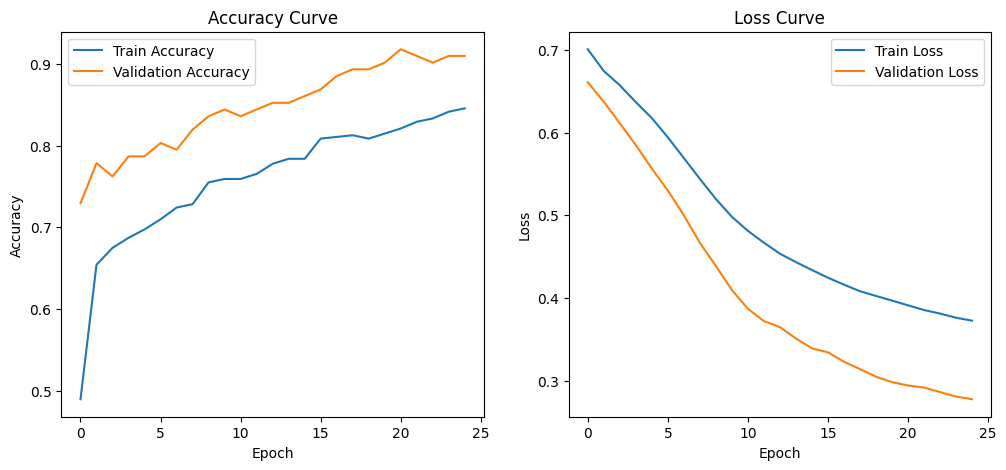

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test)
y_pred = np.round(y_pred).flatten()
cm = confusion_matrix(y_test, y_pred)
print(cm)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[[92  9]
 [11 40]]


In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate AUC
auc = roc_auc_score(y_test, y_pred)

# Print AUC as a percentage
print(f'AUC: {auc:.2f}')

AUC: 0.85


In [ ]:
# classification report
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
y_pred = np.round(y_pred).flatten()
print(classification_report(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       101
           1       0.82      0.78      0.80        51

    accuracy                           0.87       152
   macro avg       0.85      0.85      0.85       152
weighted avg       0.87      0.87      0.87       152

